# Preprocessing and EDA for Acute Oral Toxicity Dataset

This notebook:
1. Loads the dataset and inspects its structure.
2. Cleans the data (handles missing values, retains exact LD50 values).
3. Computes molecular weight from SMILES using RDKit.
4. Converts LD50 from mg/kg to -log₁₀(mol/kg).
5. Aggregates multiple measurements per SMILES by taking the median.
6. Performs EDA (summary statistics, histograms, etc.).

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 16.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the dataset

In [3]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_with_SMILES.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (16839, 21)


,Formulation Name,Chemical Name,CASRN,DTXSID,Percent Active,Mixture,Data Type,Assay,Endpoint,Response Modifier,...,Units,Species,Route,Sex,Reference,PMID,URL,Formulation ID,Record ID,SMILES
0,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Male,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_1,C1=CC(=CC=C1[N+](=O)[O-])Cl
1,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,NaN,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_2,C1=CC(=CC=C1[N+](=O)[O-])Cl
2,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Male,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_3,C1=CC(=CC=C1[N+](=O)[O-])Cl
3,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,NaN,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_4,C1=CC(=CC=C1[N+](=O)[O-])Cl
4,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Female,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_5,C1=CC(=CC=C1[N+](=O)[O-])Cl


## 2. Initial inspection and cleaning

In [4]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16839 entries, 0 to 16838
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Formulation Name   4659 non-null   object 
 1   Chemical Name      16835 non-null  object 
 2   CASRN              16839 non-null  object 
 3   DTXSID             16187 non-null  object 
 4   Percent Active     4559 non-null   float64
 5   Mixture            16839 non-null  object 
 6   Data Type          16839 non-null  object 
 7   Assay              16839 non-null  object 
 8   Endpoint           16839 non-null  object 
 9   Response Modifier  15180 non-null  object 
 10  Response           16703 non-null  float64
 11  Units              13624 non-null  object 
 12  Species            16616 non-null  object 
 13  Route              16839 non-null  object 
 14  Sex                5010 non-null   object 
 15  Reference          11634 non-null  object 
 16  PMID               0 n

In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

Missing values per column:
 Formulation Name     12180
Chemical Name            4
DTXSID                 652
Percent Active       12280
Response Modifier     1659
Response               136
Units                 3215
Species                223
Sex                  11829
Reference             5205
PMID                 16839
URL                  10204
Formulation ID       12180
SMILES                 218
dtype: int64


In [6]:
# The 'SMILES' column is crucial; drop rows without SMILES
df = df.dropna(subset=['SMILES']).copy()
print(f"Shape after dropping missing SMILES: {df.shape}")

Shape after dropping missing SMILES: (16621, 21)


In [7]:
# Examine the 'Response' column – it contains the LD50 values
# Some entries have non‑numeric modifiers (>, <) stored in 'Response Modifier'
print("Unique Response Modifier values:", df['Response Modifier'].unique())

# Keep only exact values (no modifier)
# Response Modifier appears as '  ' (two spaces) for exact numbers, or blanks
# We'll keep rows where the modifier is empty string or NaN after stripping
df['Response Modifier'] = df['Response Modifier'].astype(str).str.strip()
exact_mask = (df['Response Modifier'] == '') | (df['Response Modifier'].isna())
df_exact = df[exact_mask].copy()
print(f"Number of exact measurements: {len(df_exact)}")

# Convert Response to numeric
df_exact['Response'] = pd.to_numeric(df_exact['Response'], errors='coerce')
df_exact = df_exact.dropna(subset=['Response']).copy()
print(f"Valid numeric responses: {len(df_exact)}")

Unique Response Modifier values: ['  ' '>  ' '<  ' nan]
Number of exact measurements: 10797
Valid numeric responses: 10667


In [8]:
# Keep only rat oral data (though the dataset seems already rat oral)
df_exact = df_exact[df_exact['Species'].str.contains('rat', case=False, na=False)]
df_exact = df_exact[df_exact['Route'].str.contains('oral', case=False, na=False)]
print(f"Rat oral only: {len(df_exact)}")

# Check units – all should be mg/kg
print(df_exact['Units'].value_counts())

Rat oral only: 10450
Units
mg/kg    9140
Name: count, dtype: int64


## 3. Compute molecular weight from SMILES

In [9]:
def mol_weight_from_smiles(smiles):
    """Calculate molecular weight from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

# Apply function to create MW column
df_exact['MW'] = df_exact['SMILES'].apply(mol_weight_from_smiles)
print(f"Number with valid MW: {df_exact['MW'].notna().sum()}")
df_exact = df_exact.dropna(subset=['MW']).copy()

Number with valid MW: 10450


## 4. Convert LD50 from mg/kg to -log₁₀(mol/kg)

In [10]:
# Formula: mol/kg = (LD50 in mg/kg) / (1000 * MW)
# Then -log10(mol/kg) = -log10(LD50) + log10(1000) + log10(MW)

def convert_to_neglog_molkg(row):
    ld50 = row['Response']
    mw = row['MW']
    molkg = ld50 / (1000.0 * mw)          # mol per kg body weight
    if molkg <= 0:
        return np.nan
    return -np.log10(molkg)

df_exact['neglog_molkg'] = df_exact.apply(convert_to_neglog_molkg, axis=1)
df_exact = df_exact.dropna(subset=['neglog_molkg']).copy()

print(f"After conversion, shape: {df_exact.shape}")
df_exact[['SMILES', 'Response', 'MW', 'neglog_molkg']].head()

After conversion, shape: (10450, 23)


,SMILES,Response,MW,neglog_molkg
0,C1=CC(=CC=C1[N+](=O)[O-])Cl,294.0,157.556,2.729088
1,C1=CC(=CC=C1[N+](=O)[O-])Cl,420.0,157.556,2.574186
2,C1=CC(=CC=C1[N+](=O)[O-])Cl,500.0,157.556,2.498465
3,C1=CC(=CC=C1[N+](=O)[O-])Cl,530.0,157.556,2.473159
4,C1=CC(=CC=C1[N+](=O)[O-])Cl,565.0,157.556,2.445386


## 5. Aggregate multiple values per SMILES (median)

In [11]:
# Group by SMILES and compute median of neglog_molkg
# Also keep first chemical name for reference, and count of measurements
agg_df = df_exact.groupby('SMILES').agg({
    'neglog_molkg': 'median',
    'Chemical Name': 'first',
    'Response': 'count'                # number of original measurements
}).rename(columns={'Response': 'n_measurements'}).reset_index()

print(f"Unique compounds after aggregation: {len(agg_df)}")
agg_df.head()

# Check the distribution of n_measurements
agg_df['n_measurements'].describe()

Unique compounds after aggregation: 6708


,n_measurements
count,6708.000000
mean,1.557841
std,2.765702
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,82.000000


### Justification of median aggregation

LD50 values are typically log‑normally distributed, so the geometric mean or median is more representative than the arithmetic mean. The median is robust to outliers and does not assume a parametric form. Using the median of the already transformed -log₁₀(mol/kg) values is equivalent to taking the median on the log scale, which is a standard practice in toxicology (Karmaus et al., 2022; *Journal of Cheminformatics*). When multiple measurements are available, the median provides a stable central estimate without being unduly influenced by extreme values.

## 6. Exploratory Data Analysis (EDA)

In [12]:
# Basic statistics of the transformed LD50
print(agg_df['neglog_molkg'].describe())

count    6708.000000
mean        2.588214
std         0.948205
min         0.291207
25%         1.928311
50%         2.417691
75%         3.045670
max         7.634402
Name: neglog_molkg, dtype: float64


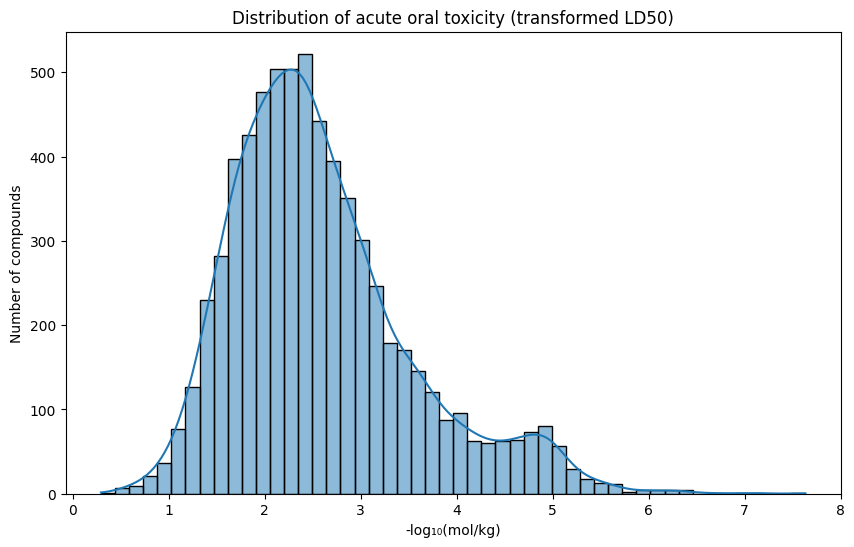

In [13]:
# Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(agg_df['neglog_molkg'], bins=50, kde=True)
plt.xlabel('-log₁₀(mol/kg)')
plt.ylabel('Number of compounds')
plt.title('Distribution of acute oral toxicity (transformed LD50)')
plt.show()

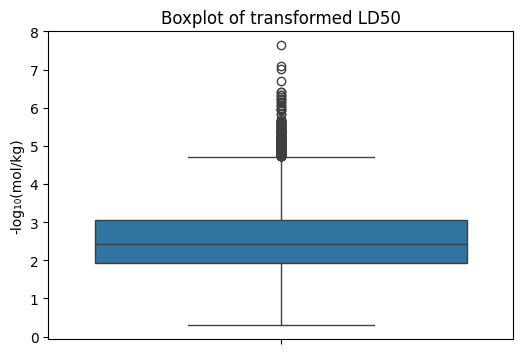

In [14]:
# Boxplot to see spread
plt.figure(figsize=(6,4))
sns.boxplot(y=agg_df['neglog_molkg'])
plt.ylabel('-log₁₀(mol/kg)')
plt.title('Boxplot of transformed LD50')
plt.show()

## 7. Save the final aggregated dataset

In [18]:
output_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_processed.csv'
agg_df.to_csv(output_path, index=False)
print(f"Saved processed data to {output_path}")

# keep only the essential columns for modeling
final_for_model = agg_df[['SMILES', 'neglog_molkg']].copy()
final_for_model.to_csv('/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_model_ready.csv', index=False)

Saved processed data to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_processed.csv
